In [ ]:
# from icrawler.builtin import BingImageCrawler
# import os

# action = "3 PT shot"
# output_dir = f"data/{action}"
# os.makedirs(output_dir, exist_ok=True)

# crawler = BingImageCrawler(storage={'root_dir': output_dir})
# crawler.crawl(keyword=f"NBA actions {action}", max_num=300, min_size=(128, 128))


Nettoyage des images et conversion JPG

In [63]:
from PIL import Image
import os

def clean_and_convert(folder):
    for root, _, files in os.walk(folder):
        for f in files:
            #print(f)
            path = os.path.join(root, f)
            try:
                img = Image.open(path).convert("RGB")
                img.save(path, "JPEG")
            except Exception:
                os.remove(path)
                print(f"⚠️ Supprimée : {path}")


In [64]:
for action in ["Dunk", "LayUp", "JumpShot"]:
    clean_and_convert(f'data/{action}')

# DATA PREPROCESSING
Split des ensembles de train val et test
preprocessing sur les img : normalisation, augmentation, etc...

##  Split des ensembles

In [ ]:
# scripts/split_dataset.py
import os, shutil, random, pathlib

# ----- Réglages -----
BASE_DIR = "data"          # dossier de base (contenant des sous-dossiers par classe)
OUT_DIR = "dataset"        # dossier de sortie (sera créé)
SPLITS = {"train": 0.70, "val": 0.15, "test": 0.15}
RANDOM_SEED = 42
ALLOWED_EXT = {".jpg"}

random.seed(RANDOM_SEED)

# ----- Création des dossiers de sortie -----
for split in SPLITS:
    os.makedirs(os.path.join(OUT_DIR, split), exist_ok=True)

# ----- Parcours des classes -----
for class_name in os.listdir(BASE_DIR):
    class_src = os.path.join(BASE_DIR, class_name)
    if not os.path.isdir(class_src):
        continue

    # liste d'images valides
    files = [
        f for f in os.listdir(class_src)
        if pathlib.Path(f).suffix.lower() in ALLOWED_EXT
    ]
    random.shuffle(files)

    n = len(files)
    n_train = int(SPLITS["train"] * n)
    n_val   = int(SPLITS["val"] * n)
    n_test  = n - n_train - n_val

    split_map = {
        "train": files[:n_train],
        "val":   files[n_train:n_train+n_val],
        "test":  files[n_train+n_val:]
    }

    for split, split_files in split_map.items():
        dst_dir = os.path.join(OUT_DIR, split, class_name)
        os.makedirs(dst_dir, exist_ok=True)
        for fname in split_files:
            src = os.path.join(class_src, fname)
            dst = os.path.join(dst_dir, fname)
            # si un nom existe déjà, on ajoute un suffixe
            if os.path.exists(dst):
                stem = pathlib.Path(fname).stem
                ext  = pathlib.Path(fname).suffix
                k = 1
                while os.path.exists(dst):
                    dst = os.path.join(dst_dir, f"{stem}_{k}{ext}")
                    k += 1
            shutil.copy2(src, dst)

print("Split terminé. Dossiers créés dans:", OUT_DIR)


✅ Split terminé. Dossiers créés dans: dataset


## Image preprocessing

In [ ]:
img_size = (180, 180)
batch_size = 16

In [67]:
import tensorflow as tf

# ----- Chargement des datasets -----
train_ds = tf.keras.utils.image_dataset_from_directory(
    "dataset/train",
    image_size=img_size,
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "dataset/val",
    image_size=img_size,
    batch_size=batch_size
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    "dataset/test",
    image_size=img_size,
    batch_size=batch_size
)

# Sauvegarde des classes AVANT toute transformation
class_names = train_ds.class_names
num_classes = len(class_names)

# ----- Normalisation des pixels [0, 1] -----
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds   = val_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds  = test_ds.map(lambda x, y: (normalization_layer(x), y))


Found 245 files belonging to 3 classes.
Found 51 files belonging to 3 classes.
Found 56 files belonging to 3 classes.


In [68]:
print(f'{num_classes} classes : {class_names}')

3 classes : ['Dunk', 'JumpShot', 'LayUp']


Data augmentation sur le train set

In [69]:
from tensorflow import keras
from tensorflow.keras import layers

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])



train_ds = train_ds.map(lambda x, y: (data_augmentation(x), y))


Affichage des images préparées

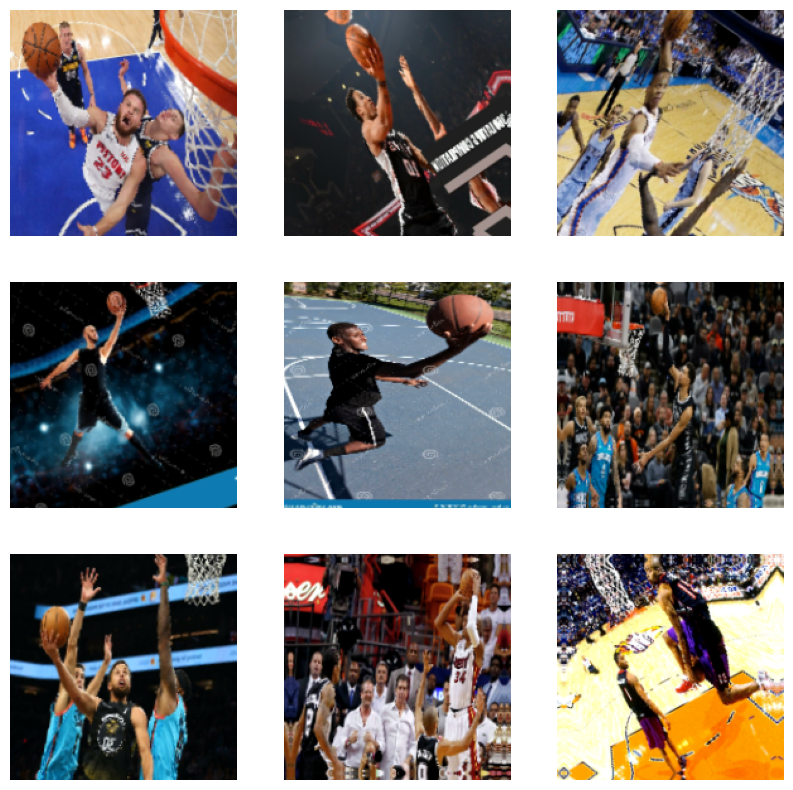

In [70]:
import matplotlib.pyplot as plt
import numpy as np

images, labels = next(iter(train_ds))

plt.figure(figsize=(10, 10))
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(np.clip(images[i].numpy(), 0, 1))
    plt.axis("off")
plt.show()



Optimisation avec prechargement

In [71]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = (train_ds
    .shuffle(1000)
    .cache()
    .prefetch(buffer_size=AUTOTUNE)
)

val_ds = (val_ds
    .cache()
    .prefetch(buffer_size=AUTOTUNE)
)

test_ds = (test_ds
    .cache()
    .prefetch(buffer_size=AUTOTUNE)
)


# Modele de prédiction CNN

## Architecture du modèle

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

# Charger le backbone MobileNetV2 (pré-entraîné sur ImageNet)
base_model = keras.applications.MobileNetV2(
    input_shape=(img_size[0], img_size[1], 3),
    include_top=False,        # On enlève la couche dense finale de ImageNet
    weights="imagenet"        # On réutilise les poids pré-entraînés
)

# On "gèle" le backbone au début (pas d'entraînement sur ces couches)
#base_model.trainable = False
base_model.trainable = True
# On ne fine-tune que les derniers blocs
for layer in base_model.layers[:-30]:  
    layer.trainable = False


# Modèle complet
model = keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),   # Remplace le Flatten, plus adapté ici
    layers.BatchNormalization(),   # normalise activations → plus stable
    layers.Dense(128, activation="relu", kernel_regularizer=keras.regularizers.l2(1e-4)),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation="softmax")
])



configuration d'une metrique qui maximise l'accuracy et minimise la loss

In [77]:
class AccuracyLossMetric(tf.keras.metrics.Metric):
    def __init__(self, alpha=0.5, name="accuracy_loss_metric", **kwargs):
        super().__init__(name=name, **kwargs)
        self.alpha = alpha
        self.total = self.add_weight(name="total", initializer="zeros")
        self.count = self.add_weight(name="count", initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        # Cast pour être sûr que les types correspondent
        y_true = tf.cast(y_true, tf.int32)
        y_pred_labels = tf.cast(tf.argmax(y_pred, axis=1), tf.int32)

        # Accuracy
        accuracy = tf.reduce_mean(tf.cast(tf.equal(y_true, y_pred_labels), tf.float32))

        # Loss (sparse categorical crossentropy)
        loss = tf.reduce_mean(tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred))

        # Métrique combinée
        metric_value = self.alpha * accuracy - (1 - self.alpha) * loss

        self.total.assign_add(metric_value)
        self.count.assign_add(1)

    def result(self):
        return self.total / self.count

    def reset_state(self):
        self.total.assign(0.0)
        self.count.assign(0.0)


In [78]:
# --- Métrique personnalisée ---
accuracy_loss_metric = AccuracyLossMetric(alpha=0.5)

# --- Compilation du modèle ---
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy", accuracy_loss_metric]
)

# --- Callback EarlyStopping ---
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="accuracy_loss_metric",  # on surveille notre métrique personnalisée
    patience=5,                      # nombre d'époques sans amélioration avant arrêt
    mode="max",                      # on veut maximiser cette métrique
    restore_best_weights=True        # remet les meilleurs poids à la fin
)


model.summary()

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 6, 6, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_9      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,427,459 (9.26 MB)

 Trainable params: 1,693,315 (6.46 MB)

 Non-trainable params: 734,144 (2.80 MB)

## Entrainement du Modèle

In [79]:
# --- Entraînement ---
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[early_stop]
)


Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 21s 327ms/step - accuracy: 0.9429 - accuracy_loss_metric: 0.3932 - loss: 0.1870 - val_accuracy: 0.4510 - val_accuracy_loss_metric: -4.8945 - val_loss: 7.9933
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 136ms/step - accuracy: 0.7796 - accuracy_loss_metric: 0.0553 - loss: 0.7283 - val_accuracy: 0.4902 - val_accuracy_loss_metric: -4.4901 - val_loss: 6.3605
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 143ms/step - accuracy: 0.8204 - accuracy_loss_metric: 0.0305 - loss: 0.7826 - val_accuracy: 0.5490 - val_accuracy_loss_metric: -3.9149 - val_loss: 6.6593
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 140ms/step - accuracy: 0.8449 - accuracy_loss_metric: 0.1470 - loss: 0.5174 - val_accuracy: 0.6078 - val_accuracy_loss_metric: -4.6586 - val_loss: 6.3332
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 144ms/step - accuracy: 0.9184 - accuracy_loss_metric: 0.3451 - loss: 0.2382 - val_accuracy: 0.7647 - val_accuracy_loss_metric: -2.2199 - val_loss: 3.8521
Epoch 6/50
16/16 ━━━━━━━

## Visualisation des courbes

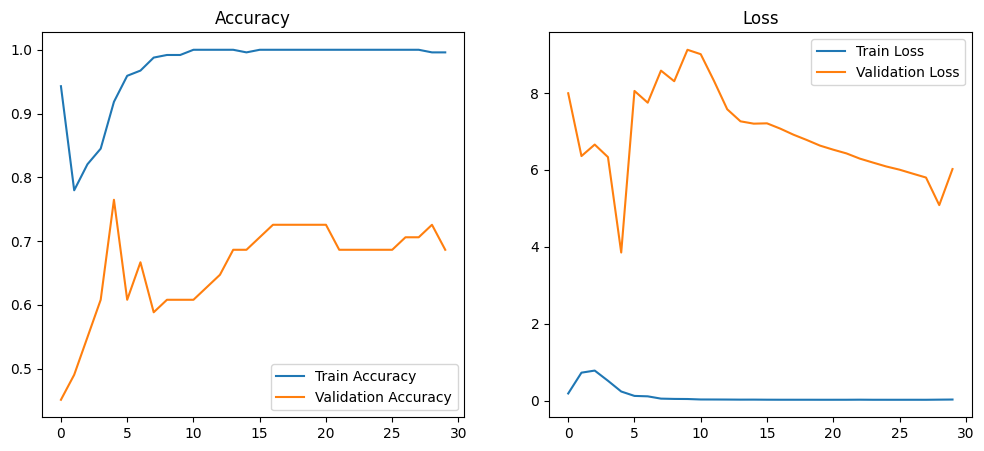

In [81]:
# -----------------------
# Visualisation des courbes
# -----------------------
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = 30
epochs_range = range(epochs)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(epochs_range, acc, label='Train Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(epochs_range, loss, label='Train Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Loss')

plt.show()


# Test et Prédictions

In [90]:
# Prédiction sur tout le dataset de test
y_pred_probs = model.predict(test_ds)  # Probabilités pour chaque classe
y_pred_labels = tf.cast(tf.argmax(y_pred_probs, axis=1), tf.int64)
y_true = tf.cast(tf.concat([y for x, y in test_ds], axis=0), tf.int64)



4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step


In [91]:
y_pred_labels,y_true

(<tf.Tensor: shape=(56,), dtype=int64, numpy=
 array([2, 2, 1, 0, 2, 1, 1, 2, 2, 1, 1, 1, 2, 0, 2, 1, 0, 1, 0, 1, 1, 0,
        1, 0, 0, 2, 0, 2, 0, 2, 0, 2, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0,
        0, 1, 2, 2, 1, 1, 0, 1, 0, 1, 1, 1])>,
 <tf.Tensor: shape=(56,), dtype=int64, numpy=
 array([2, 0, 1, 0, 2, 1, 2, 2, 0, 1, 2, 1, 2, 0, 2, 2, 0, 1, 0, 1, 1, 0,
        1, 0, 0, 2, 0, 0, 0, 2, 0, 2, 0, 1, 1, 0, 1, 0, 2, 2, 0, 0, 0, 0,
        0, 1, 2, 2, 2, 2, 0, 2, 0, 2, 1, 2])>)

In [93]:
accuracy = tf.reduce_mean(tf.cast(tf.equal(y_true, y_pred_labels), tf.float32))
print("Accuracy sur le test set :", accuracy.numpy())


Accuracy sur le test set : 0.71428573


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


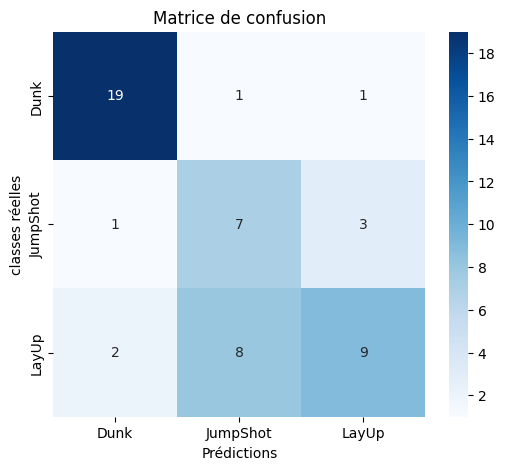

In [111]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# --- Récupérer les labels vrais et prédits ---
y_true = []
y_pred = []

for images, labels in val_ds:  # val_ds = dataset de validation
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# --- Générer la matrice de confusion ---
cm = confusion_matrix(y_true, y_pred)

# --- Affichage ---
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=class_names, 
            yticklabels=class_names)

plt.xlabel("Prédictions")
plt.ylabel("classes réelles")
plt.title("Matrice de confusion")
plt.show()


## Test sur une image random

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


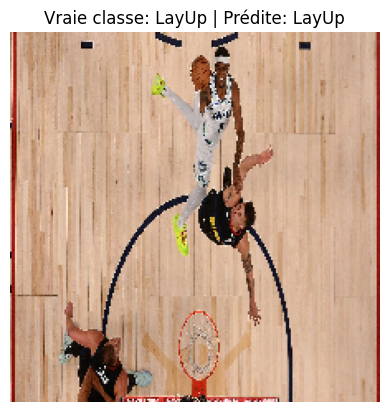

In [109]:
import random
import os
import matplotlib.pyplot as plt
import tensorflow as tf

# --- Paramètres ---
test_dir = "dataset/test"   # chemin vers ton dossier de test
img_size = (224, 224)       # la taille que tu as utilisée pour l'entraînement

# --- Choisir un fichier au hasard ---
all_classes = os.listdir(test_dir)
chosen_class = random.choice(all_classes)  # ex: "dunk"
class_path = os.path.join(test_dir, chosen_class)
random_img = random.choice(os.listdir(class_path))
img_path = os.path.join(class_path, random_img)

# --- Charger et préparer l'image ---
img = tf.keras.utils.load_img(img_path, target_size=img_size)
img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, 0) / 255.0  # normalisation

# --- Faire la prédiction ---
pred_probs = model.predict(img_array)
pred_label = tf.argmax(pred_probs, axis=1).numpy()[0]
pred_class = class_names[pred_label]

# --- Afficher ---
plt.imshow(img)
plt.axis("off")
plt.title(f"Vraie classe: {chosen_class} | Prédite: {pred_class}")
plt.show()
